## Dependencies + Imports


In [1]:
!pip list

Package                 Version
----------------------- -----------
absl-py                 2.4.0
accelerate              1.13.0
affine                  2.4.0
albucore                0.0.24
albumentations          2.0.8
annotated-doc           0.0.4
annotated-types         0.7.0
anyio                   4.13.0
asttokens               3.0.1
astunparse              1.6.3
attrs                   25.4.0
audioop-lts             0.2.2
audioread               3.1.0
beautifulsoup4          4.14.3
blinker                 1.9.0
brotli                  1.2.0
bs4                     0.0.2
certifi                 2025.11.12
cffi                    2.0.0
charset-normalizer      3.4.7
click                   8.3.2
cligj                   0.7.2
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
et_xmlfile              2.0.0
executing               2.2.1
fastapi             

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import json
import tifffile as tiff
from skimage.transform import resize
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Add, Concatenate, Flatten
from tensorflow.keras.models import Model ,load_model
from tensorflow.keras.applications import ResNet50,  EfficientNetB0
import warnings
warnings.filterwarnings('ignore')


Avoid OOM ERRORS 

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

## 1_Load The Data


Constants

In [4]:
IMG_SIZE = (64, 64)
NUM_CLASSES = 10

CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

SPECTRAL_BANDS = [
    'Coastal Aerosol',  #Very short wavelength [coastlines-shallow water-atmospheric correction]
    'Blue',             #[haze-water-coastlinees]
    'Green',            #[vegie-foorest]
    'Red',              #Rare in agricultre and veggies(absorbed)
    'Red Edge 1',       #these 3 + the below one, can tell veggies changes and crops health
    'Red Edge 2',
    'Red Edge 3',
    'NIR',              #'near infra red 'Healthy plants reflect lots of NIR but Dead plants do not 
    'Red Edge 4',       # very close to NIR 
    'Water Vapor',      #[cloud-atmosphere condition]
    'SWIR Cirrus',      #[thin cirrus clouds]
    'SWIR 1',           #'Shortwave infrared 1 '[soil moisture-fires-burned areas] 
    'SWIR 2' ,          #[minerals-geology-drought-moisture]
    'NDVI'              # the 14's i added it
]

In [5]:
DATA_ROOT = r"C:\college\CourseDataSci\final 2026\EuroSAT\allBands"

def load_satellite_data(dataset_dir, img_size=IMG_SIZE):

    data = []
    labels = []
    class_folders = sorted(os.listdir(dataset_dir))

    for class_name in class_folders:

        class_path = os.path.join(dataset_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            img_path = os.path.join(class_path, file_name)

            try:

                img = tiff.imread(img_path)

                if img.shape[-1] != 13:
                    print(f"Skipping {img_path}")
                    continue

                img = resize(
                    img,
                    (img_size[0], img_size[1], 13),
                    preserve_range=True,
                    anti_aliasing=True
                )

                # ← These two lines were missing
                data.append(img)
                labels.append(class_name)

            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    X = np.array(data)
    Y = np.array(labels)

    return X, Y

    X = np.array(data)
    Y = np.array(labels)
    return X, Y

# Load data
# DATA_ROOT ="..EuroSATallBands"


X, Y = load_satellite_data(DATA_ROOT)

print(f"\n{len(X)} images loaded successfully.")
print(f"Data shape: {X.shape}")
print(f"Classes found: {sorted(CLASSES)}")



27597 images loaded successfully.
Data shape: (27597, 64, 64, 13)
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## NDVI


In [6]:
RED_BAND = 3
NIR_BAND = 7

epsilon = 1e-6

red = X[:, :, :, RED_BAND]
nir = X[:, :, :, NIR_BAND]

ndvi = (nir - red) / (nir + red + epsilon)

# Add NDVI as the 14th channel
X = np.concatenate(
    [X, ndvi[..., np.newaxis]],
    axis=-1
)

print("Dataset shape after NDVI:", X.shape)

Dataset shape after NDVI: (27597, 64, 64, 14)


## MODELS

In [7]:
# to have y from strings (annualcrop, highway, etc..) to numbers (0,1,.....)
le = LabelEncoder()            
y_encoded = le.fit_transform(Y)
# from (0,1,2,3...) to [1,0,0,0...],[0,1,0,0,0....] by one-hot encoding
Y_onehot = to_categorical(y_encoded, num_classes=len(np.unique(Y)))

### Spliting DataSet

In [8]:
# Train + Temp (80% train, 20% temp)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y_onehot, test_size=0.2, random_state=42, stratify=Y_onehot
)
#Train + Temp (10% valid, 10% test)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)

print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 22077, Validation: 2760, Test: 2760


## NORMALIZATION

In [9]:
'''X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Mean and std computed ONLY from training set
mean = np.mean(X_train, axis=(0,1,2), keepdims=True)
std = np.std(X_train, axis=(0,1,2), keepdims=True)

std = np.where(std < 1e-6, 1.0, std)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Normalization complete.")'''

'X_train = X_train.astype(np.float32)\nX_val = X_val.astype(np.float32)\nX_test = X_test.astype(np.float32)\n\n# Mean and std computed ONLY from training set\nmean = np.mean(X_train, axis=(0,1,2), keepdims=True)\nstd = np.std(X_train, axis=(0,1,2), keepdims=True)\n\nstd = np.where(std < 1e-6, 1.0, std)\n\nX_train = (X_train - mean) / std\nX_val = (X_val - mean) / std\nX_test = (X_test - mean) / std\n\nprint("Normalization complete.")'

## Data Augmentation

Before training, we build a `tf.data` pipeline that applies random geometric augmentation (flips, rotation, zoom, translation) to the **training set only**. These transforms are purely spatial, so they work correctly even though our images have 13 spectral bands instead of the usual 3 (RGB). Augmentation helps the models generalize better and reduces overfitting, especially for the smaller/scratch-built architectures.


In [10]:
'''BATCH_SIZE = 16

# Keras preprocessing layers are purely spatial (flip/rotate/zoom/shift),
# so they apply cleanly to our 13-band images just like they would to RGB images.
data_augmentation = tf.keras.Sequential([


    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    

], name="augmentation")


def build_train_dataset(X, Y, batch_size=BATCH_SIZE, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.shuffle(buffer_size=len(X), seed=42)
    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_eval_dataset(X, Y, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Training data gets augmented; validation stays clean so it reflects real performance.
train_ds = build_train_dataset(X_train, Y_train, augment=True)
val_ds = build_eval_dataset(X_val, Y_val)

# Dictionary to keep a reference to every trained model so we can run Grad-CAM
# and compare them later without re-training.
trained_models = {}

print("train_ds and val_ds are ready (augmentation applied to training only).")
'''

'BATCH_SIZE = 16\n\n# Keras preprocessing layers are purely spatial (flip/rotate/zoom/shift),\n# so they apply cleanly to our 13-band images just like they would to RGB images.\ndata_augmentation = tf.keras.Sequential([\n\n\n    tf.keras.layers.RandomRotation(0.15),\n\n    tf.keras.layers.RandomZoom(\n        height_factor=0.10,\n        width_factor=0.10\n    ),\n\n    \n\n], name="augmentation")\n\n\ndef build_train_dataset(X, Y, batch_size=BATCH_SIZE, augment=True):\n    ds = tf.data.Dataset.from_tensor_slices((X, Y))\n    ds = ds.shuffle(buffer_size=len(X), seed=42)\n    if augment:\n        ds = ds.map(\n            lambda x, y: (data_augmentation(x, training=True), y),\n            num_parallel_calls=tf.data.AUTOTUNE\n        )\n    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)\n    return ds\n\n\ndef build_eval_dataset(X, Y, batch_size=BATCH_SIZE):\n    ds = tf.data.Dataset.from_tensor_slices((X, Y))\n    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)\n    return ds

## PRINCIPAL COMPONENT ANALYSIS (PCA)

In [12]:
# =============================================================================
# SECTION 5: PRINCIPAL COMPONENT ANALYSIS
# =============================================================================

from sklearn.decomposition import IncrementalPCA


SEED_VALUE = 42

# Flatten images
train_flat = X_train.reshape(len(X_train), -1)
val_flat   = X_val.reshape(len(X_val), -1)
test_flat  = X_test.reshape(len(X_test), -1)

print("Original flattened shape:", train_flat.shape)

N_COMPONENTS = 300
BATCH_SIZE = 512

ipca = IncrementalPCA(
    n_components=N_COMPONENTS,
    batch_size=BATCH_SIZE
)

print("\nFitting Incremental PCA...")

for i in range(0, train_flat.shape[0], BATCH_SIZE):
    ipca.partial_fit(train_flat[i:i+BATCH_SIZE])

print("Transforming training data...")

train_pca = []

for i in range(0, train_flat.shape[0], BATCH_SIZE):
    train_pca.append(
        ipca.transform(train_flat[i:i+BATCH_SIZE])
    )

train_pca = np.vstack(train_pca)

print("Transforming validation data...")
val_pca = ipca.transform(val_flat)

print("Transforming test data...")
test_pca = ipca.transform(test_flat)

print("\nDone!")

print("="*60)
print("PCA SUMMARY")
print("="*60)

print("Original train :", train_flat.shape)
print("Reduced train  :", train_pca.shape)

print("Original val   :", val_flat.shape)
print("Reduced val    :", val_pca.shape)

print("Original test  :", test_flat.shape)
print("Reduced test   :", test_pca.shape)

print(f"\nCompression Ratio : {train_flat.shape[1]/train_pca.shape[1]:.2f}x")
print(f"Explained Variance : {np.sum(ipca.explained_variance_ratio_):.2%}")

Original flattened shape: (22077, 57344)

Fitting Incremental PCA...
Transforming training data...
Transforming validation data...
Transforming test data...

Done!
PCA SUMMARY
Original train : (22077, 57344)
Reduced train  : (22077, 300)
Original val   : (2760, 57344)
Reduced val    : (2760, 300)
Original test  : (2760, 57344)
Reduced test   : (2760, 300)

Compression Ratio : 191.15x
Explained Variance : 97.11%


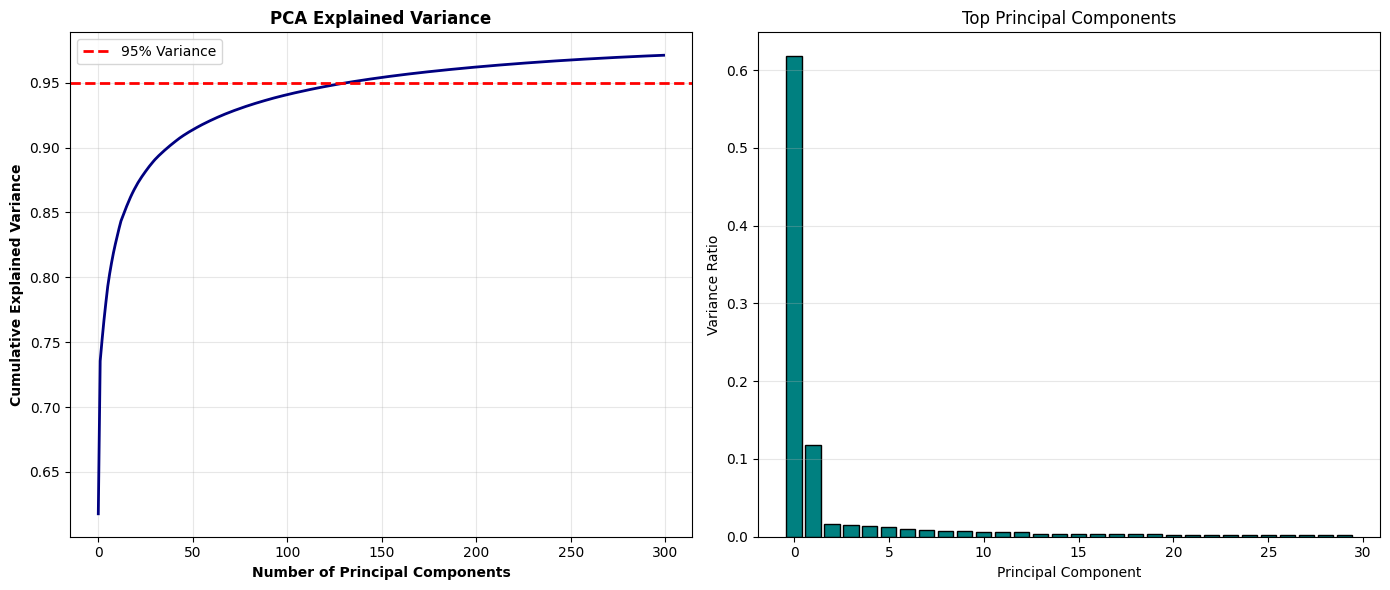

In [13]:
# =============================================================================
# PCA VARIANCE ANALYSIS
# =============================================================================

fig = plt.figure(figsize=(14,6))

# ------------------------
# Left plot
# ------------------------

ax1 = fig.add_subplot(1,2,1)

cumulative_variance = np.cumsum(
    ipca.explained_variance_ratio_
)

ax1.plot(
    cumulative_variance,
    linewidth=2,
    color="navy"
)

ax1.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    linewidth=2,
    label="95% Variance"
)

ax1.set_xlabel("Number of Principal Components", fontweight="bold")
ax1.set_ylabel("Cumulative Explained Variance", fontweight="bold")
ax1.set_title("PCA Explained Variance", fontweight="bold")
ax1.grid(alpha=0.3)
ax1.legend()

# ------------------------
# Right plot
# ------------------------

ax2 = fig.add_subplot(1,2,2)

num_display = min(
    30,
    len(ipca.explained_variance_ratio_)
)

ax2.bar(
    range(num_display),
    ipca.explained_variance_ratio_[:num_display],
    color="teal",
    edgecolor="black"
)

ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Variance Ratio")
ax2.set_title("Top Principal Components")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("PCA_ExplainedVariance.png", dpi=300)
plt.show()

In [16]:
'''# =============================================================================
# 2D PCA VISUALIZATION
# =============================================================================

print("Creating 2D PCA visualization...")

y_encoded = np.argmax(Y_train, axis=1)

pca_visual = IncrementalPCA(
    n_components=2,
    batch_size=256
)

train_pca_2d = pca_visual.fit_transform(train_flat)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    train_pca_2d[:,0],
    train_pca_2d[:,1],
    c=y_encoded,
    cmap="tab10",
    s=8,
    alpha=0.7
)

cbar = plt.colorbar(scatter)

cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASSES)

plt.xlabel("Principal Component 1", fontweight="bold")
plt.ylabel("Principal Component 2", fontweight="bold")
plt.title("2D PCA Projection of EuroSAT Dataset", fontweight="bold")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("PCA_2D_Visualization.png", dpi=300)

plt.show()

print("PCA visualization completed.")'''

'# =============================================================================\n# 2D PCA VISUALIZATION\n# =============================================================================\n\nprint("Creating 2D PCA visualization...")\n\ny_encoded = np.argmax(Y_train, axis=1)\n\npca_visual = IncrementalPCA(\n    n_components=2,\n    batch_size=256\n)\n\ntrain_pca_2d = pca_visual.fit_transform(train_flat)\n\nplt.figure(figsize=(10,8))\n\nscatter = plt.scatter(\n    train_pca_2d[:,0],\n    train_pca_2d[:,1],\n    c=y_encoded,\n    cmap="tab10",\n    s=8,\n    alpha=0.7\n)\n\ncbar = plt.colorbar(scatter)\n\ncbar.set_ticks(range(NUM_CLASSES))\ncbar.set_ticklabels(CLASSES)\n\nplt.xlabel("Principal Component 1", fontweight="bold")\nplt.ylabel("Principal Component 2", fontweight="bold")\nplt.title("2D PCA Projection of EuroSAT Dataset", fontweight="bold")\nplt.grid(alpha=0.2)\n\nplt.tight_layout()\nplt.savefig("PCA_2D_Visualization.png", dpi=300)\n\nplt.show()\n\nprint("PCA visualization complete

In [17]:
def predict_in_batches(keras_model, X, batch_size=16):
    """Predict in small manual chunks so we never hold a duplicate copy of the
    whole array in memory at once (avoids MemoryError on large test sets)."""
    preds = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i + batch_size]
        preds.append(keras_model.predict(batch, verbose=0))
    return np.concatenate(preds, axis=0)


# Collects Accuracy/Precision/Recall/F1 for every model so we can build one
# combined comparison table at the end instead of hardcoding numbers by hand.
model_metrics = {}


## 1.Light Weight CNN

In [18]:
def SpectrumNet_lite(input_shape=(64,64,13), num_classes=10):
    X_input = Input(input_shape)

    X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)

    def block(X, f):
        shortcut = X #to save the input
        X1 = Conv2D(f, (1,1), padding='same')(X)  #learnschannel
        X2 = Conv2D(f, (3,3), padding='same')(X)  #learns texture and neighbors
        X = Concatenate()([X1, X2])  #stack them
        X = BatchNormalization()(X)
        X = Activation("relu")(X) #not linear to learn cmplx
        if shortcut.shape[-1] == X.shape[-1]:
            X = Add()([shortcut, X])
        return X

    X = block(X, 32)
    X = MaxPooling2D((2,2))(X)
    X = block(X, 64)
    X = MaxPooling2D((2,2))(X)

    X = GlobalAveragePooling2D()(X) #averages each feature map into a single number ,reduce overfitting
    X = Dense(128, activation='relu')(X)# 128 neuron combine el extracted feature for prediction 
    X = Dropout(0.4)(X) #leave 40% out so u wont overfit
    X = Dense(num_classes, activation='softmax')(X) #here we use softmax

    return Model(inputs=X_input, outputs=X)

model = SpectrumNet_lite(input_shape=(64,64,13), num_classes=len(le.classes_))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 13)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      2,080 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,464 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 64)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d[0][0],     │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 128) │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p

 Total params: 81,098 (316.79 KB)

 Trainable params: 80,714 (315.29 KB)

 Non-trainable params: 384 (1.50 KB)

In [21]:
model = SpectrumNet_lite(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "SpectrumNet_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("SpectrumNet_final.h5")

Epoch 1/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6263 - loss: 1.0746
Epoch 1: val_accuracy improved from None to 0.52645, saving model to SpectrumNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.7169 - loss: 0.8135 - val_accuracy: 0.5264 - val_loss: 1.4616
Epoch 2/40
1378/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8046 - loss: 0.5514
Epoch 2: val_accuracy improved from 0.52645 to 0.87862, saving model to SpectrumNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8233 - loss: 0.5110 - val_accuracy: 0.8786 - val_loss: 0.3427
Epoch 3/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8483 - loss: 0.4436
Epoch 3: val_accuracy did not improve from 0.87862
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8548 - loss: 0.4276 - val_accuracy: 0.8569 - val_loss: 0.3892
Epoch 4/40
1378/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8681 - loss: 0.3859
Epoch 4: val_accuracy did not improve from 0.87862
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8705 - loss: 0.3792 - val_accuracy: 0.8493 - val_loss: 0.4394
Epoch 5/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8779 - loss: 0.3654
Epoch 5: val_accuracy improved from 0.87862 to 0.88913, saving model to SpectrumNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.8837 - loss: 0.3488 - val_accuracy: 0.8891 - val_loss: 0.3310
Epoch 6/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8893 - loss: 0.3282
Epoch 6: val_accuracy improved from 0.88913 to 0.89819, saving model to SpectrumNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.8907 - loss: 0.3260 - val_accuracy: 0.8982 - val_loss: 0.3197
Epoch 7/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9011 - loss: 0.2931
Epoch 7: val_accuracy did not improve from 0.89819
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.9014 - loss: 0.2955 - val_accuracy: 0.8051 - val_loss: 0.6086
Epoch 8/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9044 - loss: 0.2824
Epoch 8: val_accuracy did not improve from 0.89819
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.9054 - loss: 0.2778 - val_accuracy: 0.8779 - val_loss: 0.3520
Epoch 9/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9109 - loss: 0.2636
Epoch 9: val_accuracy improved from 0.89819 to 0.90797, saving model to SpectrumNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - accuracy: 0.9116 - loss: 0.2649 - val_accuracy: 0.9080 - val_loss: 0.2606
Epoch 10/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9165 - loss: 0.2604
Epoch 10: val_accuracy did not improve from 0.90797
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 64s 47ms/step - accuracy: 0.9154 - loss: 0.2544 - val_accuracy: 0.8232 - val_loss: 0.5708
Epoch 11/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9231 - loss: 0.2355
Epoch 11: val_accuracy did not improve from 0.90797
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9215 - loss: 0.2384 - val_accuracy: 0.8399 - val_loss: 0.4636
Epoch 12/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9224 - loss: 0.2344
Epoch 12: val_accuracy did not improve from 0.90797
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9206 - loss: 0.2398 - val_accuracy: 0.9033 - val_loss: 0.2886
Epoch 13/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9210 - loss: 0.2332

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - accuracy: 0.9246 - loss: 0.2291 - val_accuracy: 0.9210 - val_loss: 0.2163
Epoch 14/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9301 - loss: 0.2164
Epoch 14: val_accuracy did not improve from 0.92101
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.9273 - loss: 0.2209 - val_accuracy: 0.8395 - val_loss: 0.4481
Epoch 15/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9300 - loss: 0.2148
Epoch 15: val_accuracy did not improve from 0.92101
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - accuracy: 0.9313 - loss: 0.2123 - val_accuracy: 0.8185 - val_loss: 0.6795
Epoch 16/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9350 - loss: 0.2037
Epoch 16: val_accuracy did not improve from 0.92101
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.9324 - loss: 0.2110 - val_accuracy: 0.9167 - val_loss: 0.2496
Epoch 17/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9347 - loss: 0.1982


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 58s 42ms/step - accuracy: 0.9360 - loss: 0.1960 - val_accuracy: 0.9217 - val_loss: 0.2369
Epoch 19/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9374 - loss: 0.1901
Epoch 19: val_accuracy did not improve from 0.92174
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.9374 - loss: 0.1896 - val_accuracy: 0.8612 - val_loss: 0.3953
Epoch 20/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9396 - loss: 0.1860
Epoch 20: val_accuracy did not improve from 0.92174
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.9370 - loss: 0.1890 - val_accuracy: 0.7899 - val_loss: 0.8972


In [23]:
pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

acc_LightCNN = accuracy_score(y_true,y_pred)
precision_LightCNN = precision_score(y_true,y_pred,average="weighted")
recall_LightCNN = recall_score(y_true,y_pred,average="weighted")
f1_LightCNN = f1_score(y_true,y_pred,average="weighted")

print("SpectrumNet")
print("Accuracy :",acc_LightCNN)
print("Precision:",precision_LightCNN)
print("Recall :",recall_LightCNN)
print("F1 :",f1_LightCNN)

with open("SpectrumNet_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_LightCNN}\n")
    f.write(f"Precision: {precision_LightCNN}\n")
    f.write(f"Recall: {recall_LightCNN}\n")
    f.write(f"F1 Score: {f1_LightCNN}\n")

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
SpectrumNet
Accuracy : 0.9307971014492754
Precision: 0.9346934306248803
Recall : 0.9307971014492754
F1 : 0.9300356320682762


## 2.Basic CNN

In [25]:
# 5 Conv layers-3 MaxPooling layers-Flatten-Dense-Softmax

def SimpleCNN(input_shape=(64,64,14), num_classes=10):

    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)

    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)

    x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

model_cnn=SimpleCNN(input_shape=(64,64,14), num_classes=len(le.classes_))

In [26]:
model = SimpleCNN(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "SimpleCNN_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("SimpleCNN_final.h5")

Epoch 1/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4691 - loss: 21.2051
Epoch 1: val_accuracy improved from None to 0.77790, saving model to SimpleCNN_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.5874 - loss: 4.1328 - val_accuracy: 0.7779 - val_loss: 0.6832
Epoch 2/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7439 - loss: 0.7685
Epoch 2: val_accuracy improved from 0.77790 to 0.81413, saving model to SimpleCNN_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 77s 56ms/step - accuracy: 0.7495 - loss: 0.7430 - val_accuracy: 0.8141 - val_loss: 0.5109
Epoch 3/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7803 - loss: 0.6510
Epoch 3: val_accuracy improved from 0.81413 to 0.83841, saving model to SimpleCNN_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 77s 56ms/step - accuracy: 0.7835 - loss: 0.6491 - val_accuracy: 0.8384 - val_loss: 0.5435
Epoch 4/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7885 - loss: 0.6411
Epoch 4: val_accuracy did not improve from 0.83841
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 78s 57ms/step - accuracy: 0.7898 - loss: 0.6379 - val_accuracy: 0.8366 - val_loss: 0.5046
Epoch 5/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7963 - loss: 0.6176
Epoch 5: val_accuracy did not improve from 0.83841
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.7825 - loss: 0.6647 - val_accuracy: 0.6543 - val_loss: 1.0811
Epoch 6/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7999 - loss: 0.6148
Epoch 6: val_accuracy did not improve from 0.83841
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.8085 - loss: 0.5841 - val_accuracy: 0.8370 - val_loss: 0.5592
Epoch 7/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7923 - loss: 0.6322
Epoch 7

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.7917 - loss: 0.6349 - val_accuracy: 0.8649 - val_loss: 0.4639
Epoch 8/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8054 - loss: 0.5933
Epoch 8: val_accuracy did not improve from 0.86486
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.7960 - loss: 0.6283 - val_accuracy: 0.8112 - val_loss: 0.5810
Epoch 9/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8051 - loss: 0.5881
Epoch 9: val_accuracy did not improve from 0.86486
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.8134 - loss: 0.5680 - val_accuracy: 0.8395 - val_loss: 0.4864
Epoch 10/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8174 - loss: 0.5523
Epoch 10: val_accuracy did not improve from 0.86486
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.7882 - loss: 0.6586 - val_accuracy: 0.8159 - val_loss: 0.5862
Epoch 11/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8046 - loss: 0.5964
Epoc

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.8169 - loss: 0.5521 - val_accuracy: 0.8786 - val_loss: 0.3922
Epoch 13/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8131 - loss: 0.5724
Epoch 13: val_accuracy did not improve from 0.87862
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.8036 - loss: 0.6092 - val_accuracy: 0.7913 - val_loss: 0.6412
Epoch 14/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7742 - loss: 0.6868
Epoch 14: val_accuracy did not improve from 0.87862
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.7476 - loss: 0.7573 - val_accuracy: 0.7717 - val_loss: 0.6592
Epoch 15/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7839 - loss: 0.6350
Epoch 15: val_accuracy did not improve from 0.87862
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.7829 - loss: 0.6311 - val_accuracy: 0.8359 - val_loss: 0.4696
Epoch 16/40
1379/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8114 - loss: 0.5587


In [27]:
pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_CNN = accuracy_score(y_true,y_pred)
precision_CNN = precision_score(y_true,y_pred,average="weighted")
recall_CNN = recall_score(y_true,y_pred,average="weighted")
f1_CNN = f1_score(y_true,y_pred,average="weighted")

print("SimpleCNN")
print(acc_CNN,precision_CNN,recall_CNN,f1_CNN)

with open("SimpleCNN_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_CNN}\n")
    f.write(f"Precision: {precision_CNN}\n")
    f.write(f"Recall: {recall_CNN}\n")
    f.write(f"F1 Score: {f1_CNN}\n")

87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
SimpleCNN
0.8829710144927536 0.8820586788859716 0.8829710144927536 0.8815198717653203


## 2.ResNet50

In [28]:
def ResNet50_Model(input_shape=(64,64,14), num_classes=10):

    base_model = ResNet50(
        include_top=False,
        weights=None,
        input_shape=input_shape
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(base_model.input, outputs)

    return model

In [32]:
model = ResNet50_Model(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "ResNet50_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("ResNet50_final.h5")

Epoch 1/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.2958 - loss: 2.2035
Epoch 1: val_accuracy improved from None to 0.49638, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 646s 449ms/step - accuracy: 0.3228 - loss: 1.8670 - val_accuracy: 0.4964 - val_loss: 1.4794
Epoch 2/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.3829 - loss: 1.6421
Epoch 2: val_accuracy did not improve from 0.49638
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 586s 424ms/step - accuracy: 0.4076 - loss: 1.5743 - val_accuracy: 0.4192 - val_loss: 2.0717
Epoch 3/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.4795 - loss: 1.3964
Epoch 3: val_accuracy improved from 0.49638 to 0.51920, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 581s 421ms/step - accuracy: 0.5048 - loss: 1.3402 - val_accuracy: 0.5192 - val_loss: 1.8924
Epoch 4/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.5841 - loss: 1.1818
Epoch 4: val_accuracy did not improve from 0.51920
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 583s 423ms/step - accuracy: 0.5799 - loss: 1.2011 - val_accuracy: 0.1246 - val_loss: 2.2931
Epoch 5/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5163 - loss: 1.3390
Epoch 5: val_accuracy improved from 0.51920 to 0.62536, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 582s 422ms/step - accuracy: 0.5930 - loss: 1.1658 - val_accuracy: 0.6254 - val_loss: 1.1715
Epoch 6/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6730 - loss: 0.9931
Epoch 6: val_accuracy improved from 0.62536 to 0.65254, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 625s 424ms/step - accuracy: 0.6727 - loss: 0.9806 - val_accuracy: 0.6525 - val_loss: 1.2400
Epoch 7/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7308 - loss: 0.7859
Epoch 7: val_accuracy improved from 0.65254 to 0.73768, saving model to ResNet50_best.h5


...

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 574s 416ms/step - accuracy: 0.8305 - loss: 0.5244 - val_accuracy: 0.8960 - val_loss: 0.3154
Epoch 18/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8794 - loss: 0.3731
Epoch 18: val_accuracy improved from 0.89601 to 0.90471, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 622s 416ms/step - accuracy: 0.8843 - loss: 0.3611 - val_accuracy: 0.9047 - val_loss: 0.2979
Epoch 19/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8964 - loss: 0.3177
Epoch 19: val_accuracy did not improve from 0.90471
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 572s 415ms/step - accuracy: 0.8971 - loss: 0.3145 - val_accuracy: 0.8786 - val_loss: 0.3702
Epoch 20/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9074 - loss: 0.2951
Epoch 20: val_accuracy did not improve from 0.90471
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 572s 415ms/step - accuracy: 0.9055 - loss: 0.3042 - val_accuracy: 0.8514 - val_loss: 0.5062
Epoch 21/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9142 - loss: 0.2702
Epoch 21: val_accuracy did not improve from 0.90471
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 573s 415ms/step - accuracy: 0.9018 - loss: 0.3174 - val_accuracy: 0.8453 - val_loss: 0.4751
Epoch 22/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9064 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 570s 413ms/step - accuracy: 0.9249 - loss: 0.2322 - val_accuracy: 0.9348 - val_loss: 0.2692
Epoch 25/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9335 - loss: 0.2130
Epoch 25: val_accuracy did not improve from 0.93478
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 573s 415ms/step - accuracy: 0.9310 - loss: 0.2206 - val_accuracy: 0.8721 - val_loss: 0.4429
Epoch 26/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9381 - loss: 0.2020
Epoch 26: val_accuracy did not improve from 0.93478
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 572s 415ms/step - accuracy: 0.9358 - loss: 0.2085 - val_accuracy: 0.9018 - val_loss: 0.3702
Epoch 27/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9429 - loss: 0.1706
Epoch 27: val_accuracy did not improve from 0.93478
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 572s 415ms/step - accuracy: 0.9388 - loss: 0.1896 - val_accuracy: 0.9196 - val_loss: 0.2539
Epoch 28/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9388 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 565s 409ms/step - accuracy: 0.9540 - loss: 0.1465 - val_accuracy: 0.9420 - val_loss: 0.3128
Epoch 33/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9588 - loss: 0.1280
Epoch 33: val_accuracy did not improve from 0.94203
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 567s 411ms/step - accuracy: 0.9539 - loss: 0.1467 - val_accuracy: 0.8873 - val_loss: 0.4026
Epoch 34/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9499 - loss: 0.1766
Epoch 34: val_accuracy did not improve from 0.94203
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 568s 412ms/step - accuracy: 0.9560 - loss: 0.1450 - val_accuracy: 0.9355 - val_loss: 0.2426
Epoch 35/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9617 - loss: 0.1154
Epoch 35: val_accuracy improved from 0.94203 to 0.95290, saving model to ResNet50_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 569s 412ms/step - accuracy: 0.9592 - loss: 0.1319 - val_accuracy: 0.9529 - val_loss: 0.1931
Epoch 36/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9613 - loss: 0.1142
Epoch 36: val_accuracy did not improve from 0.95290
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 562s 407ms/step - accuracy: 0.9611 - loss: 0.1194 - val_accuracy: 0.8957 - val_loss: 0.6175
Epoch 37/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9623 - loss: 0.1124
Epoch 37: val_accuracy did not improve from 0.95290
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 561s 407ms/step - accuracy: 0.9627 - loss: 0.1149 - val_accuracy: 0.8478 - val_loss: 0.6337
Epoch 38/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9663 - loss: 0.1066
Epoch 38: val_accuracy did not improve from 0.95290
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 566s 410ms/step - accuracy: 0.9654 - loss: 0.1111 - val_accuracy: 0.9036 - val_loss: 0.3629
Epoch 39/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9665 - l

In [ ]:
pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_resN = accuracy_score(y_true,y_pred)
precision_resN = precision_score(y_true,y_pred,average="weighted")
recall_resN = recall_score(y_true,y_pred,average="weighted")
f1_resN = f1_score(y_true,y_pred,average="weighted")

print("ResNet50")
print(acc_resN,precision_resN,recall_resN,f1_resN)

with open("ResNet50_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_resN}\n")
    f.write(f"Precision: {precision_resN}\n")
    f.write(f"Recall: {recall_resN}\n")
    f.write(f"F1 Score: {f1_resN}\n")

87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step
ResNet50
0.9471014492753623 0.9482391557641978 0.9471014492753623 0.9470362631140536


## 3.EfficientNet

In [ ]:
def EfficientNet_Model(input_shape=(64,64,14), num_classes=10):

    base_model = EfficientNetB0(
        include_top=False,
        weights=None,
        input_shape=input_shape
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(base_model.input, outputs)

    return model

In [ ]:
model = EfficientNet_Model(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "EfficientNet_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("EfficientNet_final.h5")

Epoch 1/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4885 - loss: 1.5076
Epoch 1: val_accuracy improved from None to 0.80833, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 290s 190ms/step - accuracy: 0.6044 - loss: 1.1768 - val_accuracy: 0.8083 - val_loss: 0.6953
Epoch 2/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7700 - loss: 0.7458
Epoch 2: val_accuracy did not improve from 0.80833
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 241s 175ms/step - accuracy: 0.7855 - loss: 0.6983 - val_accuracy: 0.7949 - val_loss: 0.6342
Epoch 3/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8077 - loss: 0.6076
Epoch 3: val_accuracy improved from 0.80833 to 0.86739, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 239s 173ms/step - accuracy: 0.8227 - loss: 0.5741 - val_accuracy: 0.8674 - val_loss: 0.4214
Epoch 4/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8383 - loss: 0.5361
Epoch 4: val_accuracy improved from 0.86739 to 0.88261, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 241s 174ms/step - accuracy: 0.8266 - loss: 0.5721 - val_accuracy: 0.8826 - val_loss: 0.5177
Epoch 5/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8344 - loss: 0.5316
Epoch 5: val_accuracy improved from 0.88261 to 0.89420, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 239s 173ms/step - accuracy: 0.8306 - loss: 0.5352 - val_accuracy: 0.8942 - val_loss: 0.3329
Epoch 6/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8301 - loss: 0.5426
Epoch 6: val_accuracy did not improve from 0.89420
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 237s 171ms/step - accuracy: 0.8053 - loss: 0.6107 - val_accuracy: 0.7928 - val_loss: 0.6069
Epoch 7/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8069 - loss: 0.5745
Epoch 7: val_accuracy did not improve from 0.89420
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 239s 173ms/step - accuracy: 0.8307 - loss: 0.5157 - val_accuracy: 0.8543 - val_loss: 0.4438
Epoch 8/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8709 - loss: 0.4046
Epoch 8: val_accuracy improved from 0.89420 to 0.92645, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 237s 172ms/step - accuracy: 0.8767 - loss: 0.3885 - val_accuracy: 0.9264 - val_loss: 0.2310
Epoch 9/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8936 - loss: 0.3307
Epoch 9: val_accuracy did not improve from 0.92645
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 235s 170ms/step - accuracy: 0.8941 - loss: 0.3299 - val_accuracy: 0.9239 - val_loss: 0.2291
Epoch 10/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9077 - loss: 0.2979
Epoch 10: val_accuracy improved from 0.92645 to 0.93043, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 236s 171ms/step - accuracy: 0.9087 - loss: 0.2913 - val_accuracy: 0.9304 - val_loss: 0.2249
Epoch 11/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9156 - loss: 0.2668
Epoch 11: val_accuracy did not improve from 0.93043
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 276s 181ms/step - accuracy: 0.9172 - loss: 0.2624 - val_accuracy: 0.8993 - val_loss: 0.3042
Epoch 12/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9222 - loss: 0.2495
Epoch 12: val_accuracy did not improve from 0.93043
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 236s 171ms/step - accuracy: 0.9230 - loss: 0.2491 - val_accuracy: 0.9272 - val_loss: 0.2112
Epoch 13/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9348 - loss: 0.2076
Epoch 13: val_accuracy improved from 0.93043 to 0.95072, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 237s 171ms/step - accuracy: 0.9337 - loss: 0.2140 - val_accuracy: 0.9507 - val_loss: 0.1859
Epoch 14/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9393 - loss: 0.1970
Epoch 14: val_accuracy did not improve from 0.95072
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 238s 172ms/step - accuracy: 0.9364 - loss: 0.2059 - val_accuracy: 0.9359 - val_loss: 0.2086
Epoch 15/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9414 - loss: 0.1822
Epoch 15: val_accuracy did not improve from 0.95072
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 238s 172ms/step - accuracy: 0.9355 - loss: 0.2004 - val_accuracy: 0.9377 - val_loss: 0.2122
Epoch 16/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9461 - loss: 0.1731
Epoch 16: val_accuracy did not improve from 0.95072
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 239s 174ms/step - accuracy: 0.9454 - loss: 0.1741 - val_accuracy: 0.9496 - val_loss: 0.1465
Epoch 17/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9540 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 242s 176ms/step - accuracy: 0.9521 - loss: 0.1546 - val_accuracy: 0.9569 - val_loss: 0.1457
Epoch 20/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9615 - loss: 0.1249
Epoch 20: val_accuracy did not improve from 0.95688
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 244s 177ms/step - accuracy: 0.9612 - loss: 0.1230 - val_accuracy: 0.9543 - val_loss: 0.1584
Epoch 21/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9487 - loss: 0.1577
Epoch 21: val_accuracy did not improve from 0.95688
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 246s 178ms/step - accuracy: 0.9410 - loss: 0.1849 - val_accuracy: 0.9482 - val_loss: 0.1676
Epoch 22/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9571 - loss: 0.1362
Epoch 22: val_accuracy did not improve from 0.95688
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 244s 177ms/step - accuracy: 0.9578 - loss: 0.1331 - val_accuracy: 0.8862 - val_loss: 0.3155
Epoch 23/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9616 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 241s 175ms/step - accuracy: 0.9686 - loss: 0.1013 - val_accuracy: 0.9609 - val_loss: 0.1366
Epoch 26/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9699 - loss: 0.0931
Epoch 26: val_accuracy did not improve from 0.96087
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 241s 175ms/step - accuracy: 0.9687 - loss: 0.1011 - val_accuracy: 0.9351 - val_loss: 0.2233
Epoch 27/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9738 - loss: 0.0888
Epoch 27: val_accuracy did not improve from 0.96087
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 244s 177ms/step - accuracy: 0.9690 - loss: 0.0994 - val_accuracy: 0.9272 - val_loss: 0.2514
Epoch 28/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9690 - loss: 0.1035
Epoch 28: val_accuracy did not improve from 0.96087
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 241s 175ms/step - accuracy: 0.9494 - loss: 0.1638 - val_accuracy: 0.9322 - val_loss: 0.2543
Epoch 29/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9536 - l

In [ ]:
pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_effN = accuracy_score(y_true,y_pred)
precision_effN = precision_score(y_true,y_pred,average="weighted")
recall_effN = recall_score(y_true,y_pred,average="weighted")
f1_effN = f1_score(y_true,y_pred,average="weighted")

print("EfficientNet")
print(acc_effN,precision_effN,recall_effN,f1_effN)

with open("EfficientNet_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_effN}\n")
    f.write(f"Precision: {precision_effN}\n")
    f.write(f"Recall: {recall_effN}\n")
    f.write(f"F1 Score: {f1_effN}\n")

87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step
EfficientNet
0.9615942028985507 0.9617546141336981 0.9615942028985507 0.9615509508737415


In [ ]:
import os

for f in sorted(os.listdir()):
    if f.endswith(".h5"):
        print(f)

EfficientNet_best.h5
EfficientNet_final.h5
ResNet50_best.h5
ResNet50_final.h5
SimpleCNN_best.h5
SimpleCNN_final.h5
SpectrumNet_best.h5
SpectrumNet_final.h5
best_model.h5


# Compare 4 Models

In [ ]:
MODEL_FOLDER = r"C:\college\CourseDataSci\final 2026\finally"

models = {
    "SpectrumNet": "SpectrumNet_final.h5",
    "SimpleCNN": "SimpleCNN_final.h5",
    "ResNet50": "ResNet50_final.h5",
    "EfficientNet": "EfficientNet_final.h5"
}

results = []

for model_name, model_path in models.items():

    print(f"Evaluating {model_name}...")

    full_path = os.path.join(MODEL_FOLDER, model_path)

    model = load_model(full_path)

    predictions = model.predict(X_test, verbose=0)

    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

comparison = pd.DataFrame(results)

print(comparison)

comparison.to_csv("Model_Comparison.csv", index=False)

print("Comparison saved as Model_Comparison.csv")

Evaluating SpectrumNet...


Evaluating SimpleCNN...
Evaluating ResNet50...


Evaluating EfficientNet...


          Model  Accuracy  Precision    Recall  F1 Score
0   SpectrumNet  0.973551   0.974025  0.973551  0.973611
1     SimpleCNN  0.936957   0.938122  0.936957  0.936918
2      ResNet50  0.947101   0.948239  0.947101  0.947036
3  EfficientNet  0.961594   0.961755  0.961594  0.961551
Comparison saved as Model_Comparison.csv


Evaluating SpectrumNet


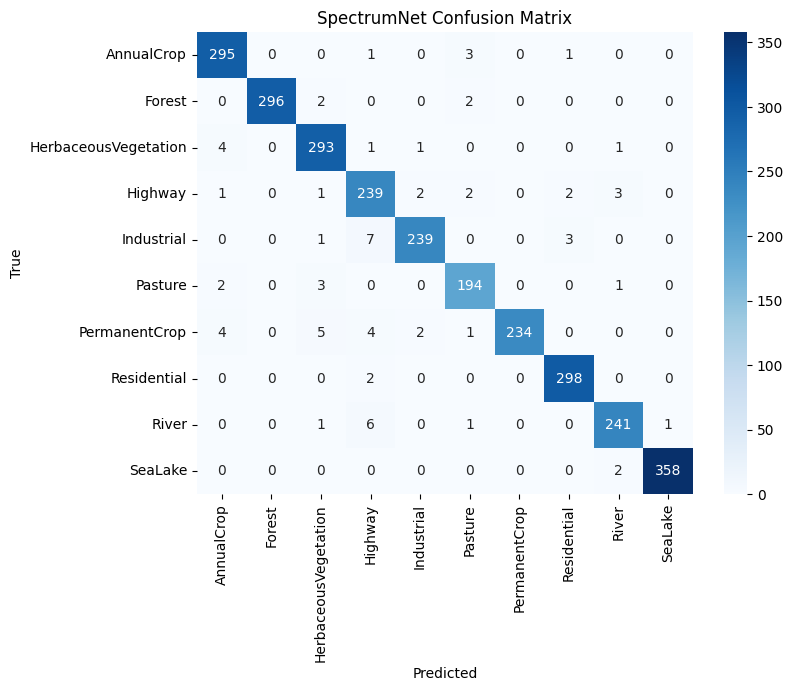

Evaluating SimpleCNN


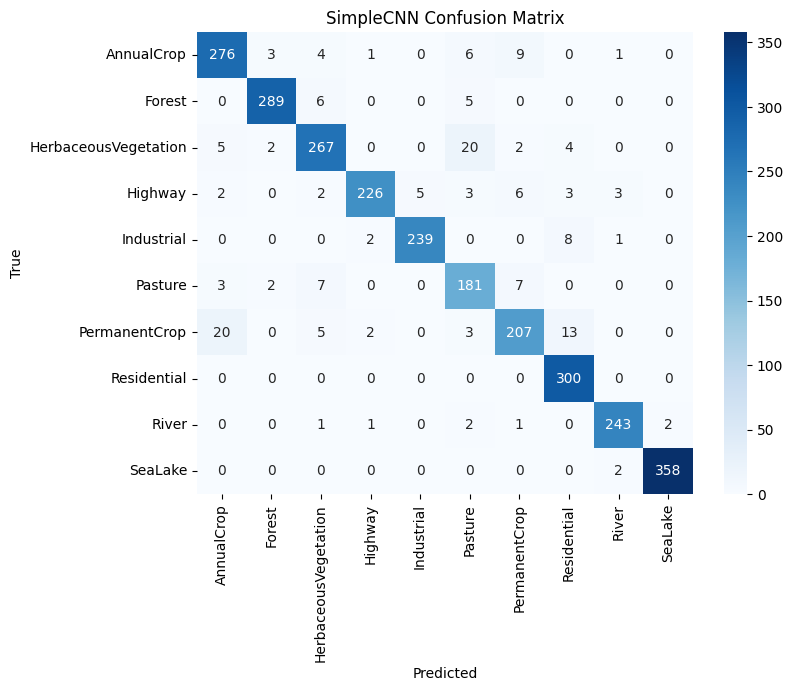

Evaluating ResNet50


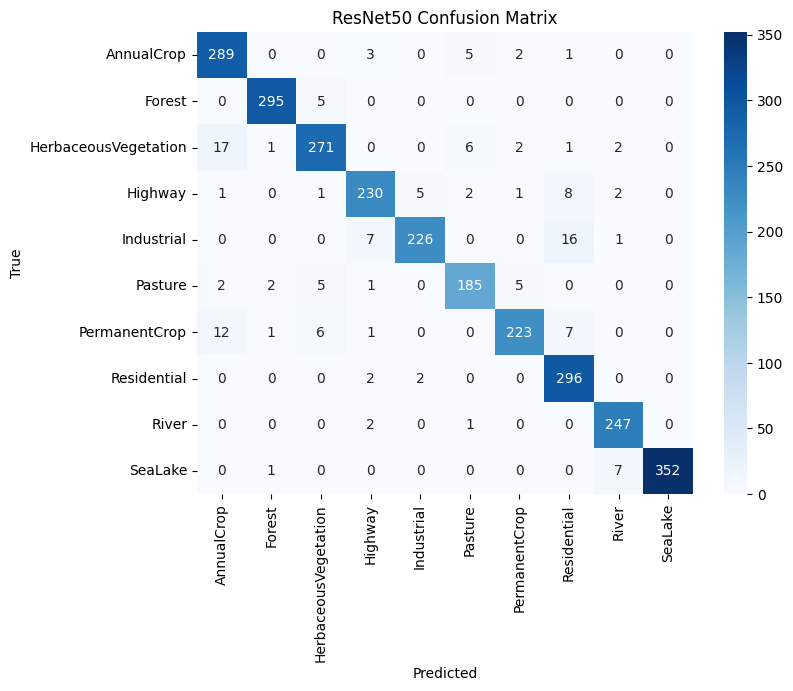

Evaluating EfficientNet


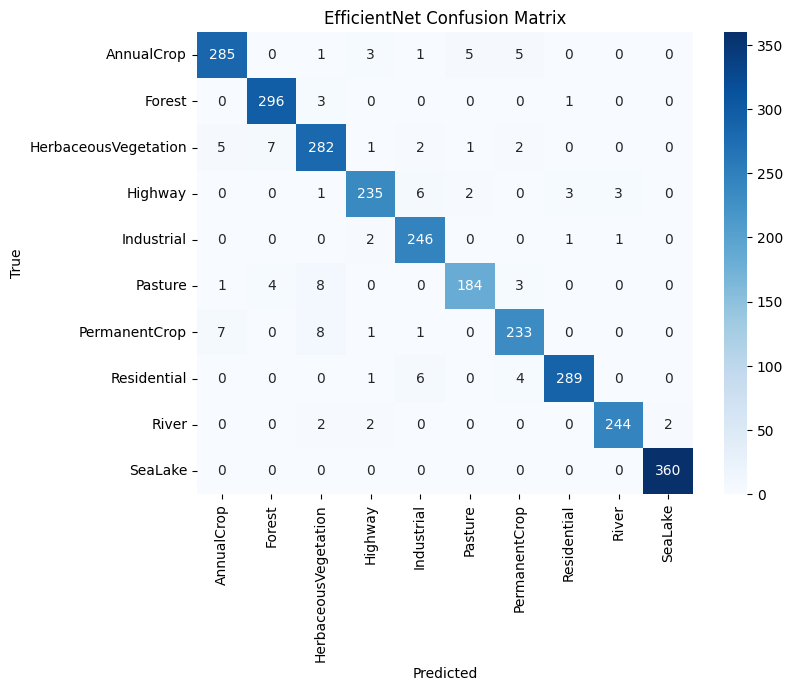

In [ ]:
for name, file in models.items():

    print(f"Evaluating {name}")

    model = load_model(os.path.join(MODEL_FOLDER, file))

    pred = model.predict(X_test, verbose=0)

    y_pred = np.argmax(pred, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

In [ ]:
y_true = np.argmax(Y_test, axis=1)

y_test_bin = label_binarize(
    y_true,
    classes=range(len(le.classes_))
)

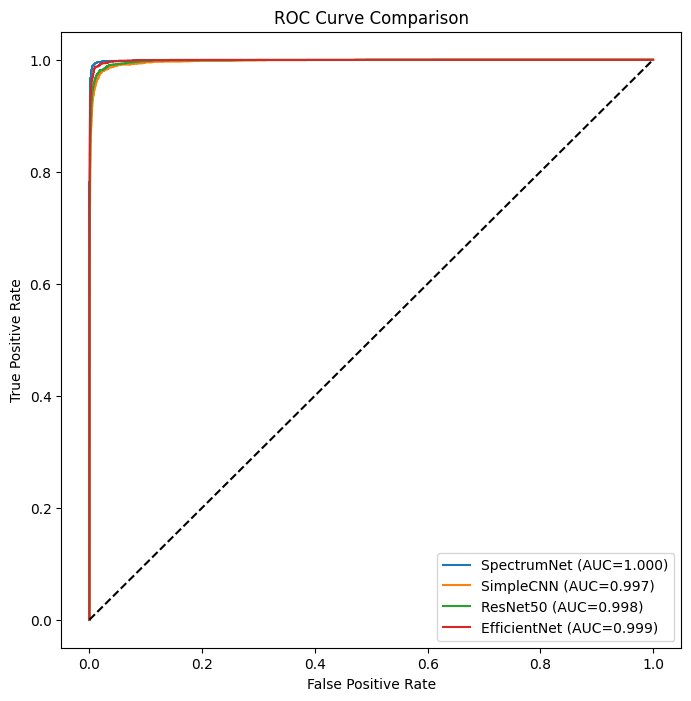

In [ ]:

plt.figure(figsize=(8,8))

for name, file in models.items():

    model = load_model(os.path.join(MODEL_FOLDER, file))

    pred = model.predict(X_test, verbose=0)

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        pred.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Grad-CAM


In [ ]:
image = X_test[44]
img = np.expand_dims(image, axis=0)

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def display_gradcam(image, heatmap):

    heatmap = cv2.resize(heatmap,(64,64))

    heatmap = np.uint8(255*heatmap)

    heatmap = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)

    image = image[:,:,:3]

    image = image.astype(np.float32)

    image = (image-image.min())/(image.max()-image.min())

    image = np.uint8(255*image)

    superimposed = cv2.addWeighted(image,0.6,heatmap,0.4,0)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [ ]:
index = 15

image = X_test[index]

img_array = np.expand_dims(image,axis=0)
from tensorflow.keras.models import load_model

model = load_model("SpectrumNet_final.h5")

for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

input_layer_4 InputLayer
conv2d_15 Conv2D
conv2d_16 Conv2D
conv2d_17 Conv2D
concatenate_6 Concatenate
batch_normalization_6 BatchNormalization
activation_6 Activation
add_3 Add
max_pooling2d_6 MaxPooling2D
conv2d_18 Conv2D
conv2d_19 Conv2D
concatenate_7 Concatenate
batch_normalization_7 BatchNormalization
activation_7 Activation
max_pooling2d_7 MaxPooling2D
global_average_pooling2d_3 GlobalAveragePooling2D
dense_6 Dense
dropout_3 Dropout
dense_7 Dense


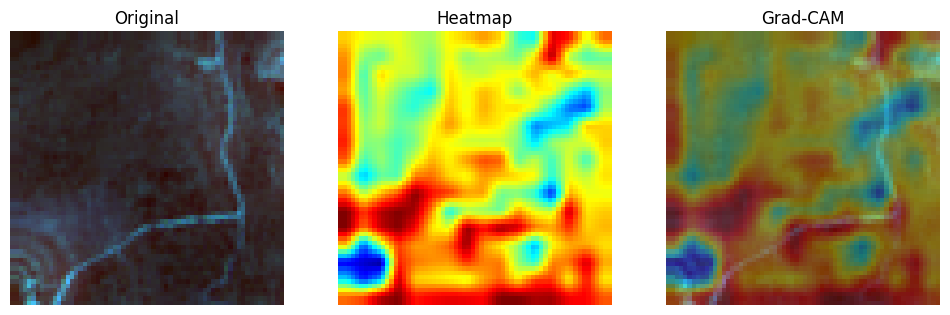

In [ ]:
import cv2
last_conv_layer_name = "conv2d_19"
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

display_gradcam(image, heatmap)

## Metric table

In [ ]:
results = []

for name, file in models.items():

    model = load_model(os.path.join(MODEL_FOLDER,file))

    pred = model.predict(X_test,verbose=0)

    y_pred = np.argmax(pred,axis=1)
    y_true = np.argmax(Y_test,axis=1)

    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_true,y_pred),
        "Precision":precision_score(y_true,y_pred,average="weighted"),
        "Recall":recall_score(y_true,y_pred,average="weighted"),
        "F1":f1_score(y_true,y_pred,average="weighted")
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1
0,SpectrumNet,0.973551,0.974025,0.973551,0.973611
1,SimpleCNN,0.936957,0.938122,0.936957,0.936918
2,ResNet50,0.947101,0.948239,0.947101,0.947036
3,EfficientNet,0.961594,0.961755,0.961594,0.961551


# Actual test

In [ ]:
def preprocess_image(image_path):

    img = tiff.imread(image_path).astype(np.float32)

    # Resize first if needed
    img = resize(
        img,
        (IMG_SIZE[0], IMG_SIZE[1], 13),
        preserve_range=True,
        anti_aliasing=True
    )

    # Sentinel-2 convention:
    # Red = band 4 (index 3)
    # NIR = band 8 (index 7)

    red = img[:, :, 3]
    nir = img[:, :, 7]

    ndvi = (nir - red) / (nir + red + 1e-8)

    # Add NDVI as the 14th channel
    img = np.dstack((img, ndvi))

    # IMPORTANT:
    # Use the SAME normalization used during training.
    img /= X.max()   # or 10000.0 if that's what your training code used

    img = np.expand_dims(img, axis=0)

    return img

img = tiff.imread(image_path)

print(img.shape)

(64, 64, 13)


In [33]:
model = load_model("SimpleCNN_best.h5")

image_path = r"C:\college\CourseDataSci\final 2026\EuroSAT\allBands\Pasture\Pasture_58.tif"

img = preprocess_image(image_path)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print("Predicted class:", le.inverse_transform([predicted_class])[0])
print("Confidence:", np.max(prediction))

NameError: name 'preprocess_image' is not defined